## 1. Data Pre-Processing
### Cleaning up the data fields

In [1]:
%pip install -r ../requirements.txt

Note: you may need to restart the kernel to use updated packages.



[notice] A new release of pip is available: 26.1.1 -> 26.1.2
[notice] To update, run: python.exe -m pip install --upgrade pip


In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import wordcloud
import plotly.graph_objects as go
import ipywidgets as widgets
from IPython.display import display, Markdown

In [3]:
challenges = '../output/challenges.csv'
expectations = '../output/expectations.csv'

In [4]:
df_painpoints = pd.read_csv(challenges, names=['Focus Group', 'Pain Point'], engine='python', on_bad_lines='skip')
df_expectations = pd.read_csv(expectations, names=['Focus Group', 'Expectation'], engine='python', on_bad_lines='skip')


In [5]:
df_painpoints.shape, df_expectations.shape

((453, 2), (445, 2))

In [6]:
#drop the pain_points rows containing "Other", "IPS related"
df_painpoints = df_painpoints[~df_painpoints['Pain Point'].str.contains('Other|IPS related', case=False, na=False)]
df_expectations = df_expectations[~df_expectations['Expectation'].str.contains('Other|IPS related', case=False, na=False)]

In [7]:
df_painpoints.shape, df_expectations.shape

((409, 2), (410, 2))

In [8]:
# (optional )create new column 'pain_point_desc' and split on first ':' if present
# df_painpoints['pain_point_desc'] = ''
# mask = df_painpoints['Pain Point'].fillna('').str.contains(':')
# df_painpoints.loc[mask, 'pain_point_desc'] = df_painpoints.loc[mask, 'Pain Point'].str.split(':', n=1).str[1].str.strip()
# df_painpoints.loc[mask, 'Pain Point'] = df_painpoints.loc[mask, 'Pain Point'].str.split(':', n=1).str[0].str.strip()

# #create new column 'expectation_desc' and split on first ':' if present
# df_expectations['expectation_desc'] = ''
# mask = df_expectations['Expectation'].fillna('').str.contains(':')
# df_expectations.loc[mask, 'expectation_desc'] = df_expectations.loc[mask, 'Expectation'].str.split(':', n=1).str[1].str.strip()
# df_expectations.loc[mask, 'Expectation'] = df_expectations.loc[mask, 'Expectation'].str.split(':', n=1).str[0].str.strip()

In [9]:
# create a new column to represent the string length of the pain point and expectation
df_painpoints['word_count'] = df_painpoints['Pain Point'].str.split().str.len()
df_expectations['word_count'] = df_expectations['Expectation'].str.split().str.len()

In [10]:
df_painpoints.sample(5, random_state=42)

,Focus Group,Pain Point,word_count
193,DOCE Building Inspectors,Need for Personal Hotspots: Inspectors sometim...,12
152,DOCE Admin Aides,Tracking ownership changes requires extensive ...,7
139,DOCE Admin Aides,Administrative workflows are not standardized ...,7
105,DOCE Admin Aide,Property Research Challenges,3
81,DOCE Admin Aide,Case Management Challenges,3


In [11]:
df_expectations.sample(5, random_state=42)

,Focus Group,Expectation,word_count
188,DOCE CommercialPermitElectrical Inspectors,Faster Search Capabilities: Quickly locate pro...,9
151,DOCE Building Inspectors,Enhanced Case Management,3
138,DOCE Admin Aides,Improved search capabilities.,3
105,DOCE Admin Aides,Improved support for multi-unit and complex ow...,8
82,DOCE Admin Aide,Eliminate duplicate data entry where possible.,6


In [12]:
# show the rows where word_count is less than 5 for pain points and expectations
df_painpoints[df_painpoints['word_count'] <= 4]

,Focus Group,Pain Point,word_count
0,focus_group,pain_points,1
12,CPO Central Permit Office,System Fragmentation,2
17,CPO Central Permit Office,Integration Limitations,2
22,CPO Central Permit Office,Applicant Visibility Issues,3
27,CPO Central Permit Office,Application & Review Challenges,4
...,...,...,...
407,DOCE Supervisors,System Performance & Usability,4
412,DOCE Supervisors,Multiple Systems,2
416,DOCE Supervisors,Historical Information,2
420,DOCE Supervisors,Communication Challenges,2


In [13]:
#drop the rows containing less than or equal to 4 words in pain_points and expectations
df_painpoints = df_painpoints[df_painpoints['word_count'] >= 4].drop(columns=['word_count'])
df_expectations = df_expectations[df_expectations['word_count'] >= 4].drop(columns=['word_count'])

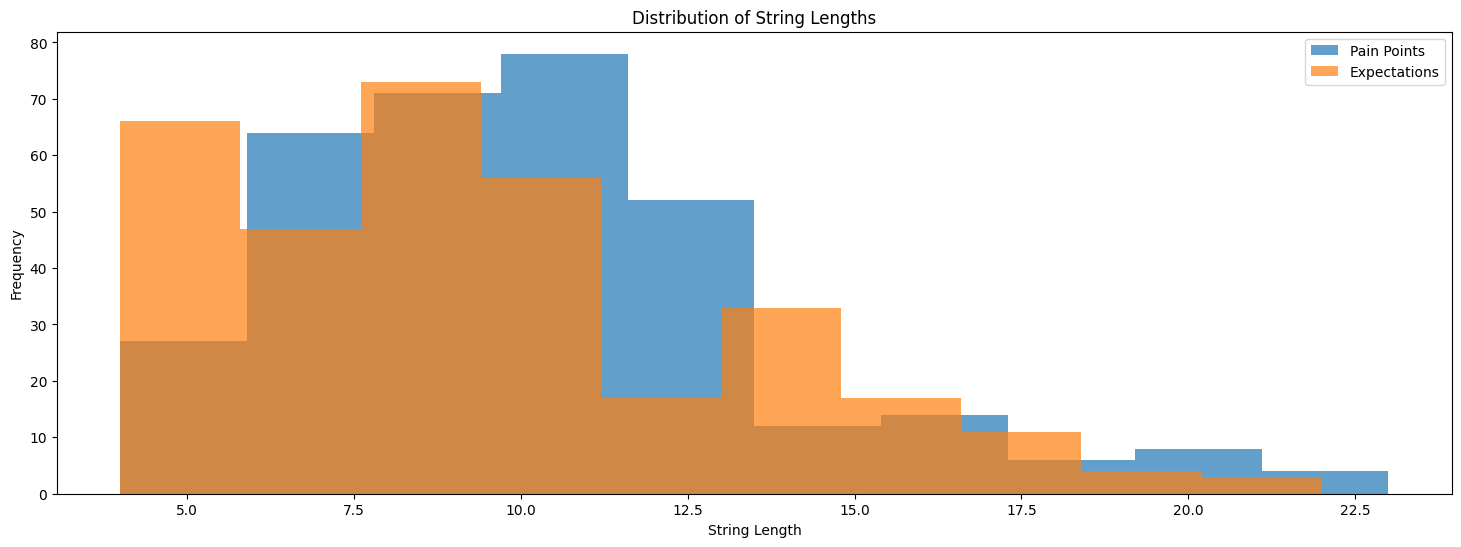

In [14]:
#plot the distribution of string lengths for pain points and expectations
plt.figure(figsize=(18, 6))
hist_pain = plt.hist(df_painpoints['Pain Point'].str.split().str.len(), alpha=0.7, label='Pain Points')
hist_expect = plt.hist(df_expectations['Expectation'].str.split().str.len(), alpha=0.7, label='Expectations')
plt.xlabel('String Length')
plt.ylabel('Frequency')
plt.title('Distribution of String Lengths')
plt.legend()

In [22]:
#drop the rows containing less than or equal to 4 words in pain_points and expectations
df_painpoints = df_painpoints[df_painpoints['Pain Point'].str.split().str.len() > 4]
df_expectations = df_expectations[df_expectations['Expectation'].str.split().str.len() > 4]

### Finder function

In [23]:
def get_pain_points(keyword, optional_keywords=None, sentiment=None):
    """
    Get pain points based on keywords.

    Parameters:
    keyword (str or list): The main keyword or keywords that must be present in the pain points.
    optional_keywords (list, optional): List of additional keywords that may also appear in the same record.
    sentiment (str, optional): The sentiment to filter by.

    Returns:
    DataFrame: Filtered DataFrame containing pain points that match the keywords.
    """
    required_keywords = keyword if isinstance(keyword, list) else [keyword]
    required_mask = df_painpoints['processed_content'].str.contains('|'.join(required_keywords), case=False, na=False)

    filtered_pain_points = df_painpoints[required_mask]

    if optional_keywords:
        optional_mask = filtered_pain_points['processed_content'].str.contains('|'.join(optional_keywords), case=False, na=False)
        filtered_pain_points = filtered_pain_points[optional_mask]

    if sentiment is not None:
        filtered_pain_points = filtered_pain_points[filtered_pain_points['label'] == sentiment]
    return filtered_pain_points

In [24]:
def get_expectations(keyword, optional_keywords=None, sentiment=None):
    """
    Get expectations based on keywords.

    Parameters:
    keyword (str or list): The main keyword or keywords to search for in the expectations.
    optional_keywords (list, optional): List of additional keywords to search for.
    sentiment (str, optional): The sentiment to filter by.

    Returns:
    DataFrame: Filtered DataFrame containing expectations that match the keywords.
    """
    keywords = keyword if isinstance(keyword, list) else [keyword]
    if optional_keywords:
        keywords.extend(optional_keywords)

    filtered_expectations = df_expectations[df_expectations['processed_content'].str.contains('|'.join(keywords), case=False, na=False)]
    if sentiment is not None:
        filtered_expectations = filtered_expectations[filtered_expectations['label'] == sentiment]
    return filtered_expectations

In [25]:
IPS_crashes = get_pain_points(['IPS'], optional_keywords=['crash', 'crashing','freezing', 'lag', 'slow', 'unresponsive', 'stuck', 'hang', 'freeze', 'navigat', 'interface', 'in-field', 'infield', 'in field', 'dashboard'], sentiment='negative') 
print(f"Total number of pain points related to IPS crashing issues: {len(IPS_crashes)}")

KeyError: 'processed_content'

In [ ]:
#store this as csv files for further analysis
df_painpoints.to_csv('../output/cleaned_challenges.csv', index=False)
df_expectations.to_csv('../output/cleaned_expectations.csv', index=False)

In [ ]:
#function to calculate amount of times a keyword appears in a pain point 
def count_keyword_occurrences(keyword, case_sensitive=False):
    return df_painpoints.loc[
        df_painpoints['Pain Point'].str.contains(keyword, case=case_sensitive, na=False)
    ].shape[0]

In [ ]:
count_keyword_occurrences('crash|Crash|freez|Freez|slow|Slow|lag|Lag|hang|Hang|unresponsive|Unresponsive|shutdown|Shutdown|freeze|Freeze|lock|Lock|stuck|Stuck|')

In [ ]:
# display the records where the pain point contains the keyword 'Crashes'
df_painpoints[df_painpoints['Pain Point'].str.contains('crash|Crash|freez|Freez|slow|Slow|lag|Lag|hang|Hang|unresponsive|Unresponsive|shutdown|Shutdown|freeze|Freeze|lock|Lock|stuck|Stuck|', na=False)]

In [ ]:
count_keyword_occurrences('many system|multiple system', case_sensitive=False)

In [ ]:
df_painpoints[df_painpoints['Pain Point'].str.contains('many system|multiple system', na=False)]